# GA Best Subnetwork Interpretability Analysis

This notebook investigates **why** the genetic algorithm (GA) selected the particular nodes in the
best k=8 subnetwork for the N=5000 drug-fixed-targets-v5 dataset.

**Core hypothesis**: good drug classification requires a mix of *sensitive* nodes
(high Hamming distance from control, above CUTOFF) and *insensitive* nodes (below CUTOFF).
Sensitive nodes signal that *a drug was applied*; insensitive nodes may provide complementary
information that breaks ties between drugs.

## Sections
0. Setup & Data Loading
1. Sensitivity profile of the best k=8 subnetwork (across all 50 networks)
2. Node removal ablation (single / double / triple removal)
3. Node replacement analysis (stratified sample: 100 sensitive + 100 insensitive)
4. Conditional entropy H(Drug | nodes) across GA generations
5. Additional analyses: RF feature importances, Shapley values, drug confusion matrix

## Section 0: Setup & Data Loading

In [1]:
import glob
import itertools
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from itertools import combinations
from matplotlib.patches import Patch
from scipy.stats import entropy as scipy_entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from typing import *

# Add scripts directory so we can import classifier
sys.path.insert(0, os.path.abspath('scripts'))
from classifier import train_and_test

# Add protobuf generated code
# sys.path.insert(0, os.path.abspath('python_generated'))
# import message_pb2

In [42]:
N = 5_000
NUM_NETWORKS = 50
SEED = 2025
np.random.seed(SEED)


STATES_FILE    = './data/drug-fixed-targets-v7/N5000/derived/states-1772488362007.csv'
# NETWORK_FILE   = '../data/drug-fixed-targets-v7/N5000/derived/networks-1772488362007.csv'
GA_RESULTS_DIR = './data/drug-fixed-targets-v7/N5000/ga-results-v7'
# EXPERIMENT_FILE = 'data/drug-fixed-targets-v5/N5000/raw/experiment-1771990816511-642cd1eb-a3ad-4a99-ae55-7258de7d7790.pb'
# STATES_FILE    = 'data/drug-fixed-targets-v5/N5000/derived/states-1771990942417.csv'
# NETWORK_FILE   = 'data/drug-fixed-targets-v5/N5000/derived/networks-1771990942417.csv'
# EXPERIMENT_FILE = 'data/drug-fixed-targets-v5/N5000/raw/experiment-1771990816511-642cd1eb-a3ad-4a99-ae55-7258de7d7790.pb'
# GA_RESULTS_DIR = 'data/drug-fixed-targets-v5/N5000/ga-results-v5'

PALETTE = sns.color_palette('tab10', n_colors=10)

In [36]:
print('Loading states_df (large file, may take a moment)...')
states_df = pd.read_csv(STATES_FILE)
print(f'states_df shape: {states_df.shape}')
print(f'columns: {list(states_df.columns[:6])} ...')
states_df.head(2)

Loading states_df (large file, may take a moment)...
states_df shape: (55000, 5004)
columns: ['drug_name', 'original_network_idx', 'initial_condition_idx', 'step_num', 'node-0', 'node-1'] ...


,drug_name,original_network_idx,initial_condition_idx,step_num,node-0,node-1,node-2,node-3,node-4,node-5,...,node-4990,node-4991,node-4992,node-4993,node-4994,node-4995,node-4996,node-4997,node-4998,node-4999
0,control,0,0,0,False,False,True,True,True,True,...,False,True,False,False,False,True,True,True,True,True
1,control,0,0,1,False,False,False,True,False,True,...,False,False,False,False,False,True,True,False,True,True


In [4]:
network_df = pd.read_csv(NETWORK_FILE)
print(f'network_df shape: {network_df.shape}')
network_df.head(2)

network_df shape: (3124551, 4)


,original_network_idx,source,target,weight
0,0,49,0,0.450887
1,0,750,0,0.795669


In [5]:
# experiment = message_pb2.Experiment()
# with open(EXPERIMENT_FILE, 'rb') as f:
#     experiment.ParseFromString(f.read())
# print(f'Loaded experiment with {len(experiment.results)} results')

In [43]:
# Concatenate all per-network full GA result CSVs
from pathlib import Path
full_csvs = sorted(Path(GA_RESULTS_DIR).glob('*-full.csv'))
full_csvs = [c for c in full_csvs if not c.name.startswith('combined')]
print(f'Found {len(full_csvs)} *-full.csv files')

feature_df = pd.concat(
    [pd.read_csv(f) for f in full_csvs],
    ignore_index=True,
)
# Parse the features column from string repr of set → actual set
feature_df['features'] = feature_df['features'].apply(eval)
print(f'feature_df shape: {feature_df.shape}')
print(f'Columns: {list(feature_df.columns)}')
feature_df.head(3)

Found 50 *-full.csv files
feature_df shape: (6437, 6)
Columns: ['original_network_idx', 'max_num_features', 'generation', 'best_accuracy', 'avg_accuracy', 'features']


,original_network_idx,max_num_features,generation,best_accuracy,avg_accuracy,features
0,0,1,0,0.181818,0.115455,{node-959}
1,0,1,1,0.181818,0.130909,{node-959}
2,0,1,2,0.181818,0.139091,{node-959}


In [ ]:
# feature_df[feature.max_num_features]

In [44]:
# Compute B matrix: B[network_idx, node_idx] = mean |Hamming distance from control|
# Replicates the logic from faster_hamming_dist_plot.ipynb (cell-8)

node_cols = [f'node-{i}' for i in range(N)]

df = states_df.copy().reset_index(drop=True)
df['rep'] = (df.index.to_numpy() % 10).astype(np.int64)
df = df.set_index(['original_network_idx', 'initial_condition_idx', 'rep'], drop=False)

X = df[node_cols].to_numpy(dtype=np.float64, copy=False)

is_control = (df['drug_name'] == 'control').to_numpy()
controls_mat = pd.DataFrame(X[is_control], index=df.index[is_control], columns=node_cols)

treated_idx = df.index[~is_control]
treated_mat = pd.DataFrame(X[~is_control], index=treated_idx, columns=node_cols)

aligned_controls = controls_mat.reindex(treated_mat.index)
missing = aligned_controls.isna().any(axis=1)
if missing.any():
    bad = aligned_controls.index[missing].tolist()[:10]
    raise KeyError(f'Missing control for {missing.sum()} treated keys. Example: {bad}')

diff = aligned_controls.to_numpy() - treated_mat.to_numpy()
a  = treated_idx.get_level_values(0).to_numpy(np.int64)
bi = treated_idx.get_level_values(1).to_numpy(np.int64)
ci = treated_idx.get_level_values(2).to_numpy(np.int64)

A = np.zeros((NUM_NETWORKS, 10, 10, N), dtype=np.float64)
A[a, bi, ci, :] = np.abs(diff)
B = A.mean(axis=2).mean(axis=1)  # shape: (50, N)
print(f'B matrix shape: {B.shape}')

B matrix shape: (50, 5000)


In [15]:
df

drug_name  \
original_network_idx initial_condition_idx rep             
0                    0                     0     control   
                                           1     control   
                                           2     control   
                                           3     control   
                                           4     control   
...                                                  ...   
49                   9                     5     drug-10   
                                           6     drug-10   
                                           7     drug-10   
                                           8     drug-10   
                                           9     drug-10   

                                                original_network_idx  \
original_network_idx initial_condition_idx rep                         
0                    0                     0                       0   
                                           1                       0   
                                           2                       0   
                                           3                       0   
                                           4                       0   
...                                                              ...   
49                   9                     5                      49   
                                           6                      49   
                                           7                      49   
                                           8                      49   
                                           9                      49   

                                                initial_condition_idx  \
original_network_idx initial_condition_idx rep                          
0                    0                     0                        0   
                                           1                        0   
                                           2                        0   
                                           3                        0   
                                           4                        0   
...                                                               ...   
49                   9                     5                        9   
                                           6                        9   
                                           7                        9   
                                           8                        9   
                                           9                        9   

                                                step_num  node-0  node-1  \
original_network_idx initial_condition_idx rep                             
0                    0                     0           0   False   False   
                                           1           1   False   False   
                                           2           2    True   False   
                                           3           3    True   False   
                                           4           4   False   False   
...                                                  ...     ...     ...   
49                   9                     5           5   False    True   
                                           6           6   False    True   
                                           7           7   False    True   
                                           8           8   False   False   
                                           9           9   False    True   

                                                node-2  node-3  node-4  \
original_network_idx initial_condition_idx rep                           
0                    0                     0      True    True    True   
                                           1     False    True   False   
                                           2     False   False    True   
                    

In [45]:
# Compute CUTOFF: upper confidence bound of mean Hamming dist for nodes NOT selected at k=16
# Replicates faster_hamming_dist_plot.ipynb (cells 10-11)

not_selected_means = []
for orig_idx in range(NUM_NETWORKS):
    _fdf = feature_df[
        (feature_df.original_network_idx == orig_idx) &
        (feature_df.max_num_features == 16)
    ]
    if _fdf.empty:
        continue
    max_gen = _fdf.generation.max()
    nodes_set = _fdf[_fdf.generation == max_gen].features.iloc[0]
    node_idxs = [int(n.split('-')[1]) for n in nodes_set]
    mask = np.ones(N, dtype=bool)
    mask[node_idxs] = False
    not_selected_means.append(B[orig_idx][mask].mean())

c = 1.96
arr = np.array(not_selected_means)
CUTOFF = arr.mean() + c * arr.std() / np.sqrt(len(arr))
PCT_ABOVE_CUTOFF = (B > CUTOFF).mean()

print(f'CUTOFF            = {CUTOFF:.5f}  (expect ≈0.205)')
print(f'PCT_ABOVE_CUTOFF  = {PCT_ABOVE_CUTOFF:.4f}  (expect ≈0.356)')

CUTOFF            = 0.20528  (expect ≈0.205)
PCT_ABOVE_CUTOFF  = 0.3818  (expect ≈0.356)


In [46]:
# Extract best k=8 subnetwork (final generation) for each network
best_k8 = {}
for orig_idx in range(NUM_NETWORKS):
    _fdf = feature_df[
        (feature_df.original_network_idx == orig_idx) &
        (feature_df.max_num_features == 8)
    ]
    if _fdf.empty:
        continue
    max_gen = _fdf.generation.max()
    best_row = _fdf[_fdf.generation == max_gen].iloc[0]
    node_idxs = sorted([int(n.split('-')[1]) for n in best_row.features])
    best_k8[orig_idx] = {
        'nodes': node_idxs,
        'node_cols': [f'node-{i}' for i in node_idxs],
        'accuracy': best_row.best_accuracy,
        'max_generation': max_gen,
    }

# Representative network = highest final-generation accuracy at k=8
REP_IDX = 0 # max(best_k8, key=lambda i: best_k8[i]['accuracy'])
rep_info  = best_k8[REP_IDX]
rep_nodes = rep_info['nodes']
rep_node_cols = rep_info['node_cols']

print(f'Representative network: original_network_idx = {REP_IDX}')
print(f'  k=8 nodes:    {rep_nodes}')
print(f'  k=8 accuracy: {rep_info["accuracy"]:.4f}')
print(f'  Hamming dists: {[round(B[REP_IDX][n], 3) for n in rep_nodes]}')
print(f'  Sensitive?:    {[bool(B[REP_IDX][n] > CUTOFF) for n in rep_nodes]}')

Representative network: original_network_idx = 0
  k=8 nodes:    [624, 1530, 1917, 2032, 2550, 2935, 3201, 3258]
  k=8 accuracy: 1.0000
  Hamming dists: [np.float64(0.48), np.float64(0.38), np.float64(0.71), np.float64(0.52), np.float64(0.36), np.float64(0.38), np.float64(0.4), np.float64(0.37)]
  Sensitive?:    [True, True, True, True, True, True, True, True]


In [47]:
def get_network_states(orig_idx: int) -> pd.DataFrame:
    """Return states for one network with 'Drug' column, ready for train_and_test."""
    df = states_df[states_df['original_network_idx'] == orig_idx].copy()
    df = df.rename(columns={'drug_name': 'Drug'})
    df = df.drop(columns=['original_network_idx', 'initial_condition_idx'], errors='ignore')
    return df.reset_index(drop=True)

rep_states = get_network_states(REP_IDX)
print(f'rep_states shape: {rep_states.shape}')
print(f'Drugs: {sorted(rep_states.Drug.unique())}')

rep_states shape: (1100, 5002)
Drugs: ['control', 'drug-1', 'drug-10', 'drug-2', 'drug-3', 'drug-4', 'drug-5', 'drug-6', 'drug-7', 'drug-8', 'drug-9']


## Section 1: Sensitivity Profile of the Best k=8 Subnetwork

For each of the 50 networks, how many of the 8 GA-selected nodes are
**sensitive** (Hamming dist > CUTOFF) vs **insensitive** (≤ CUTOFF)?
Compare against the background rate of sensitive nodes in the full network.

In [10]:
sensitivity_rows = []
for orig_idx, info in best_k8.items():
    for node_idx in info['nodes']:
        sensitivity_rows.append({
            'original_network_idx': orig_idx,
            'node_idx': node_idx,
            'hamming_dist': float(B[orig_idx][node_idx]),
            'sensitive': bool(B[orig_idx][node_idx] > CUTOFF),
            'k8_accuracy': info['accuracy'],
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

per_network = (
    sensitivity_df
    .groupby('original_network_idx')['sensitive']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'n_sensitive', 'count': 'k'})
)
per_network['n_insensitive'] = per_network['k'] - per_network['n_sensitive']

print(f'Mean sensitive nodes in k=8: {per_network.n_sensitive.mean():.2f} / 8')
print(f'Expected under random:       {8 * PCT_ABOVE_CUTOFF:.2f} / 8')
print(f'\nDistribution of n_sensitive:')
print(per_network.n_sensitive.value_counts().sort_index())

Mean sensitive nodes in k=8: 6.10 / 8
Expected under random:       2.85 / 8

Distribution of n_sensitive:
n_sensitive
1     2
2     2
3     1
4     4
5     6
6     7
7    16
8    12
Name: count, dtype: int64


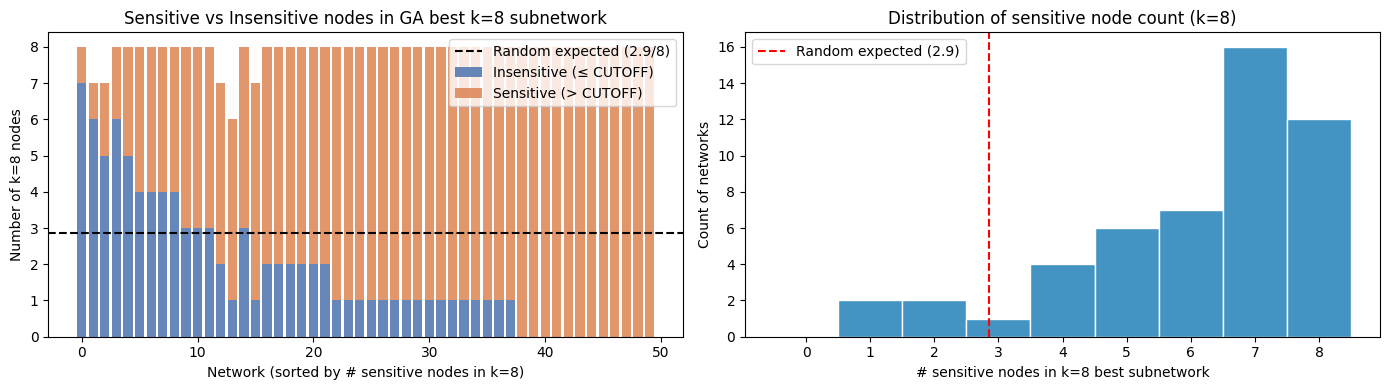

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: stacked bar per network (sorted by n_sensitive)
order = per_network.sort_values('n_sensitive').index
ax = axes[0]
bottom = np.zeros(len(order))
for label, col, color in [
    ('Insensitive (≤ CUTOFF)', 'n_insensitive', '#4C72B0'),
    ('Sensitive (> CUTOFF)',   'n_sensitive',   '#DD8452'),
]:
    vals = per_network.loc[order, col].values
    ax.bar(range(len(order)), vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += vals

ax.axhline(
    y=8 * PCT_ABOVE_CUTOFF, color='black', linestyle='--',
    label=f'Random expected ({8*PCT_ABOVE_CUTOFF:.1f}/8)'
)
ax.set_xlabel('Network (sorted by # sensitive nodes in k=8)')
ax.set_ylabel('Number of k=8 nodes')
ax.set_title('Sensitive vs Insensitive nodes in GA best k=8 subnetwork')
ax.legend()

# Right: distribution histogram
ax2 = axes[1]
bins = np.arange(-0.5, 9.5)
ax2.hist(per_network['n_sensitive'], bins=bins, color='#4393C3', edgecolor='white')
ax2.axvline(8 * PCT_ABOVE_CUTOFF, color='red', linestyle='--',
            label=f'Random expected ({8*PCT_ABOVE_CUTOFF:.1f})')
ax2.set_xlabel('# sensitive nodes in k=8 best subnetwork')
ax2.set_ylabel('Count of networks')
ax2.set_title('Distribution of sensitive node count (k=8)')
ax2.set_xticks(list(range(9)))
ax2.legend()

plt.tight_layout()
plt.show()

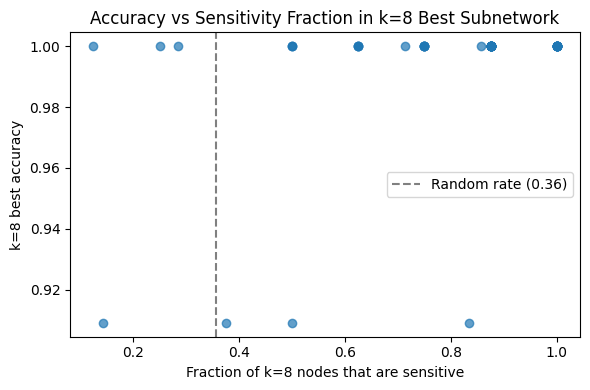

In [12]:
# Scatter: k=8 accuracy vs fraction of selected nodes that are sensitive
acc_sens = sensitivity_df.groupby('original_network_idx').agg(
    accuracy=('k8_accuracy', 'first'),
    frac_sensitive=('sensitive', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(acc_sens.frac_sensitive, acc_sens.accuracy, alpha=0.7)
ax.axvline(PCT_ABOVE_CUTOFF, color='gray', linestyle='--', label=f'Random rate ({PCT_ABOVE_CUTOFF:.2f})')
ax.set_xlabel('Fraction of k=8 nodes that are sensitive')
ax.set_ylabel('k=8 best accuracy')
ax.set_title('Accuracy vs Sensitivity Fraction in k=8 Best Subnetwork')
ax.legend()
plt.tight_layout()
plt.show()

## Section 2: Node Removal Ablation

**Question**: If we remove 1, 2, or 3 nodes from the best k=8 subnetwork,
how much does accuracy drop? Does it matter more if the removed node was sensitive or insensitive?

### 2a: Deep dive on representative network (all C(8,1)+C(8,2)+C(8,3) = 92 subsets)

In [13]:
print(f'Representative network: {REP_IDX}')
print(f'  nodes: {rep_nodes}')
print(f'  sensitivities: {[bool(B[REP_IDX][n] > CUTOFF) for n in rep_nodes]}')
print(f'  Hamming dists: {[round(B[REP_IDX][n], 3) for n in rep_nodes]}')
print()

# Baseline: all 8 nodes
perf_df, _ = train_and_test(rep_states, num_trials=3, original_network_idx=REP_IDX, dep_vars=rep_node_cols)
BASE_ACC = perf_df['correct'].mean()
print(f'Baseline accuracy (all 8 nodes): {BASE_ACC:.4f}')

removal_results = [{
    'n_removed': 0,
    'removed_nodes': [],
    'remaining_nodes': rep_nodes[:],
    'accuracy': BASE_ACC,
    'n_sensitive_removed': 0,
    'n_insensitive_removed': 0,
    'removed_label': 'none',
}]

for n_remove in [1, 2, 3]:
    for removed in combinations(rep_nodes, n_remove):
        remaining = [n for n in rep_nodes if n not in removed]
        remaining_cols = [f'node-{n}' for n in remaining]
        perf_df, _ = train_and_test(
            rep_states, num_trials=3, original_network_idx=REP_IDX, dep_vars=remaining_cols
        )
        acc = perf_df['correct'].mean()
        removed_sens = [bool(B[REP_IDX][n] > CUTOFF) for n in removed]
        n_sens = sum(removed_sens)
        n_insens = len(removed) - n_sens
        if n_sens == len(removed):
            label = 'all sensitive'
        elif n_insens == len(removed):
            label = 'all insensitive'
        else:
            label = 'mixed'
        print(f'  Removed {[f"node-{n}" for n in removed]} (sens={removed_sens}): acc={acc:.4f}  Δ={acc-BASE_ACC:+.4f}')
        removal_results.append({
            'n_removed': n_remove,
            'removed_nodes': list(removed),
            'remaining_nodes': remaining,
            'accuracy': acc,
            'n_sensitive_removed': n_sens,
            'n_insensitive_removed': n_insens,
            'removed_label': label,
        })

removal_df = pd.DataFrame(removal_results)
removal_df['accuracy_drop'] = BASE_ACC - removal_df['accuracy']

Representative network: 0
  nodes: [111, 1152, 1708, 2054, 2124, 2397, 2653, 4198]
  sensitivities: [False, False, False, True, True, True, True, True]
  Hamming dists: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.5), np.float64(0.58), np.float64(0.4), np.float64(0.5), np.float64(0.51)]

Baseline accuracy (all 8 nodes): 0.9394
  Removed ['node-111'] (sens=[False]): acc=0.9394  Δ=+0.0000
  Removed ['node-1152'] (sens=[False]): acc=0.9394  Δ=+0.0000
  Removed ['node-1708'] (sens=[False]): acc=0.9697  Δ=+0.0303
  Removed ['node-2054'] (sens=[True]): acc=0.6364  Δ=-0.3030
  Removed ['node-2124'] (sens=[True]): acc=0.7576  Δ=-0.1818
  Removed ['node-2397'] (sens=[True]): acc=0.6364  Δ=-0.3030
  Removed ['node-2653'] (sens=[True]): acc=0.7273  Δ=-0.2121
  Removed ['node-4198'] (sens=[True]): acc=0.5152  Δ=-0.4242
  Removed ['node-111', 'node-1152'] (sens=[False, False]): acc=0.9091  Δ=-0.0303
  Removed ['node-111', 'node-1708'] (sens=[False, False]): acc=0.8788  Δ=-0.0606

KeyboardInterrupt: 

NameError: name 'removal_df' is not defined

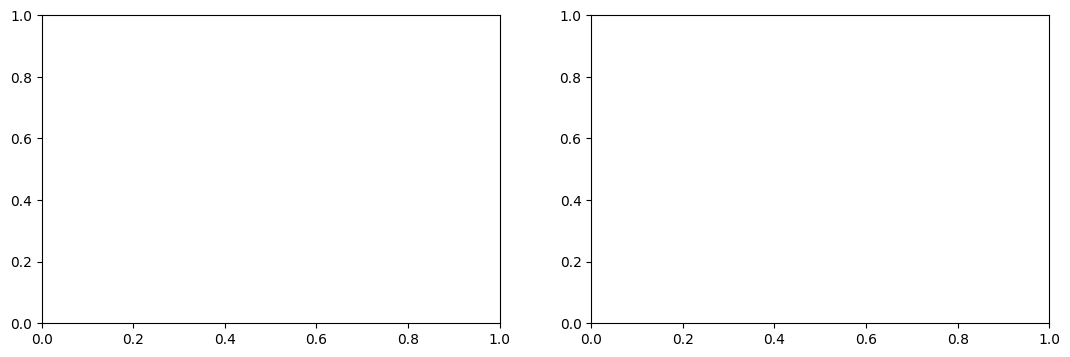

In [14]:
label_colors = {
    'none':            'gray',
    'all sensitive':   '#DD8452',
    'all insensitive': '#4C72B0',
    'mixed':           '#55A868',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: accuracy by n_removed, colored by label
ax = axes[0]
for _, row in removal_df.iterrows():
    ax.scatter(
        row['n_removed'] + np.random.uniform(-0.15, 0.15),
        row['accuracy'],
        color=label_colors[row['removed_label']],
        s=90, alpha=0.85, zorder=3,
    )
ax.axhline(BASE_ACC, color='black', linestyle='--', alpha=0.5, label='baseline')
ax.set_xlabel('Number of nodes removed')
ax.set_ylabel('Accuracy')
ax.set_title(f'Node Removal Ablation – Network {REP_IDX}')
ax.set_xticks([0, 1, 2, 3])
legend_patches = [Patch(color=c, label=l) for l, c in label_colors.items()]
ax.legend(handles=legend_patches, title='Removed nodes')

# Right: accuracy drop for single-node removals, colored by sensitivity
ax2 = axes[1]
single_df = removal_df[removal_df.n_removed == 1].copy()
single_df['removed_node'] = single_df['removed_nodes'].apply(lambda x: x[0])
single_df['sensitive'] = single_df['removed_node'].apply(lambda n: bool(B[REP_IDX][n] > CUTOFF))
single_df['label'] = single_df.apply(
    lambda r: f"node-{r['removed_node']}\n(H={B[REP_IDX][r['removed_node']]:.2f}, {'S' if r['sensitive'] else 'I'})",
    axis=1,
)
colors = ['#DD8452' if s else '#4C72B0' for s in single_df['sensitive']]
ax2.bar(single_df['label'], single_df['accuracy_drop'], color=colors)
ax2.set_xlabel('Removed node  (H = Hamming dist, S = sensitive, I = insensitive)')
ax2.set_ylabel('Accuracy drop')
ax2.set_title(f'Single-Node Removal – Network {REP_IDX}')
ax2.legend(handles=[
    Patch(color='#DD8452', label='Sensitive (> CUTOFF)'),
    Patch(color='#4C72B0', label='Insensitive (≤ CUTOFF)'),
])

plt.tight_layout()
plt.show()

### 2b: Aggregate single-node removal across all 50 networks

Does removing a sensitive node hurt more on average?

In [48]:
print('Running single-node removal across all 50 networks (1 trial each)...')

counter = 0
agg_removal_rows = []
for orig_idx, info in best_k8.items():
    net_states = get_network_states(orig_idx)
    node_list = info['nodes']
    node_list_cols = [f'node-{n}' for n in node_list]

    # Baseline
    p, _ = train_and_test(net_states, num_trials=3, original_network_idx=orig_idx, dep_vars=node_list_cols)
    base = p['correct'].mean()

    for removed_node in node_list:
        remaining_cols = [f'node-{n}' for n in node_list if n != removed_node]
        p, _ = train_and_test(net_states, num_trials=3, original_network_idx=orig_idx, dep_vars=remaining_cols)
        acc = p['correct'].mean()
        agg_removal_rows.append({
            'original_network_idx': orig_idx,
            'removed_node': removed_node,
            'removed_sensitive': bool(B[orig_idx][removed_node] > CUTOFF),
            'removed_hamming': float(B[orig_idx][removed_node]),
            'baseline_accuracy': base,
            'accuracy': acc,
            'accuracy_drop': base - acc,
        })
    print(f'  network {orig_idx}: done (base={base:.3f})', flush=True)
    counter += 1
    if counter >= 5:
      break

agg_removal_df = pd.DataFrame(agg_removal_rows)
print(f'\nDone. {len(agg_removal_df)} rows.')

Running single-node removal across all 50 networks (1 trial each)...
  network 0: done (base=0.818)
  network 1: done (base=1.000)
  network 2: done (base=0.939)
  network 3: done (base=0.879)
  network 4: done (base=0.939)

Done. 40 rows.


In [ ]:
agg_removal_df

,original_network_idx,removed_node,removed_sensitive,removed_hamming,baseline_accuracy,accuracy,accuracy_drop
0,0,624,True,0.48,0.636364,0.636364,0.000000
1,0,1530,True,0.38,0.636364,0.636364,0.000000
2,0,1917,True,0.71,0.636364,0.727273,-0.090909
3,0,2032,True,0.52,0.636364,0.818182,-0.181818
4,0,2550,True,0.36,0.636364,0.727273,-0.090909
...,...,...,...,...,...,...,...
395,49,1757,True,0.45,0.727273,0.636364,0.090909
396,49,2384,True,0.46,0.727273,0.636364,0.090909
397,49,2615,True,0.31,0.727273,0.727273,0.000000
398,49,3307,False,0.00,0.727273,0.636364,0.090909


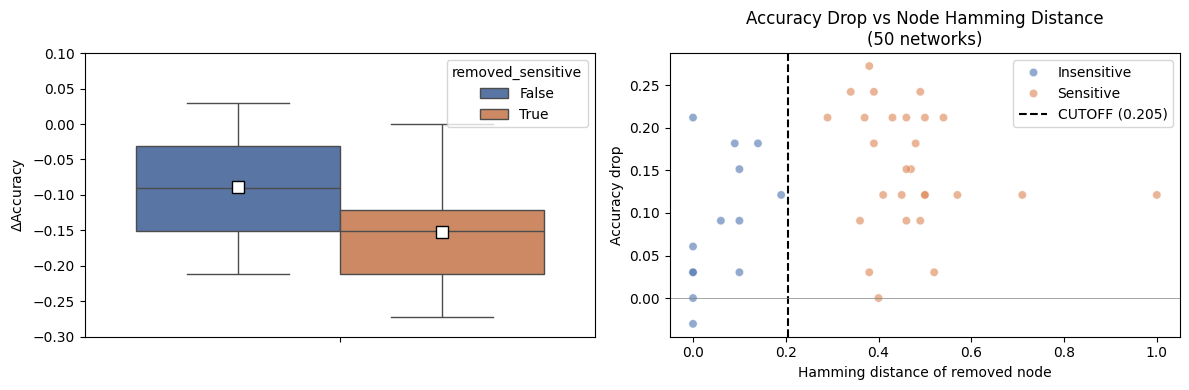


Mean accuracy drop by sensitivity:
                   count      mean       std       min       25%       50%  \
removed_sensitive                                                            
False               13.0  0.088578  0.076723 -0.030303  0.030303  0.090909   
True                27.0  0.152637  0.071553  0.000000  0.121212  0.151515   

                        75%       max  
removed_sensitive                      
False              0.151515  0.212121  
True               0.212121  0.272727  


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: boxplot of accuracy drop by sensitivity
ax = axes[0]
sns.boxplot(
    data=agg_removal_df,
    # x='removed_sensitive',
    y=-agg_removal_df['accuracy_drop'],
    palette={True: '#DD8452', False: '#4C72B0'},
    hue='removed_sensitive',
    ax=ax,
    # stat='proportion',
    # multiple='dodge',
    showmeans=True,
    meanprops={'marker': 's', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 8},
)
# ax.set_xticklabels(['Insensitive (≤ CUTOFF)', 'Sensitive (> CUTOFF)'])
# ax.set_xlabel('Sensitivity of removed node')
ax.set_ylabel('$\Delta$Accuracy')
ax.set_ylim(-.3, .1)
# ax.set_title('Accuracy Drop by Removed Node Sensitivity\n(50 networks, single-node removal)')

# Right: scatter of accuracy drop vs Hamming distance
ax2 = axes[1]
sns.scatterplot(
    data=agg_removal_df,
    x='removed_hamming',
    y='accuracy_drop',
    hue='removed_sensitive',
    palette={True: '#DD8452', False: '#4C72B0'},
    hue_order=[False, True],
    alpha=0.6,
    ax=ax2,
)
ax2.axvline(CUTOFF, color='black', linestyle='--', label=f'CUTOFF ({CUTOFF:.3f})')
ax2.axhline(0, color='gray', linestyle='-', lw=0.5)
ax2.set_xlabel('Hamming distance of removed node')
ax2.set_ylabel('Accuracy drop')
ax2.set_title('Accuracy Drop vs Node Hamming Distance\n(50 networks)')
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, ['Insensitive', 'Sensitive', f'CUTOFF ({CUTOFF:.3f})'])

plt.tight_layout()
plt.show()

print('\nMean accuracy drop by sensitivity:')
print(agg_removal_df.groupby('removed_sensitive')['accuracy_drop'].describe())

## Section 3: Node Replacement Analysis

**Question**: If we swap one node in the best k=8 subnetwork with another node,
how does accuracy change? Does it matter whether the **replaced** node (outgoing)
or the **replacement** node (incoming) is sensitive or insensitive?

**Method**: Stratified sample of 100 sensitive + 100 insensitive replacement candidates
(excluding the 8 already-selected nodes), applied to the representative network.

In [28]:
rep_selected_set = set(rep_nodes)
sens_mask = B[REP_IDX] > CUTOFF

non_sel_sensitive   = [n for n in range(N) if sens_mask[n]     and n not in rep_selected_set]
non_sel_insensitive = [n for n in range(N) if not sens_mask[n] and n not in rep_selected_set]

np.random.seed(SEED)
sample_sensitive   = np.random.choice(non_sel_sensitive,   size=100, replace=False).tolist()
sample_insensitive = np.random.choice(non_sel_insensitive, size=100, replace=False).tolist()
replacement_candidates = sample_sensitive + sample_insensitive

print(f'k=8 selected nodes (candidates for replacement): {rep_nodes}')
print(f'  sensitivities: {[bool(B[REP_IDX][n] > CUTOFF) for n in rep_nodes]}')
print(f'Replacement pool: 100 sensitive + 100 insensitive = {len(replacement_candidates)} total')
print(f'Available sensitive nodes:   {len(non_sel_sensitive)}')
print(f'Available insensitive nodes: {len(non_sel_insensitive)}')

k=8 selected nodes (candidates for replacement): [7, 555, 2670, 3218, 3318, 3482, 4087, 4372]
  sensitivities: [True, False, True, False, True, False, True, True]
Replacement pool: 100 sensitive + 100 insensitive = 200 total
Available sensitive nodes:   899
Available insensitive nodes: 4093


In [29]:
total_evals = len(rep_nodes) * len(replacement_candidates)
print(f'Running {total_evals} replacement experiments (1 trial each)...')

replacement_rows = []
for slot_idx, replaced_node in enumerate(rep_nodes):
    replaced_sensitive = bool(B[REP_IDX][replaced_node] > CUTOFF)
    print(f'  Slot {slot_idx}: replacing node-{replaced_node} (sensitive={replaced_sensitive})...', flush=True)
    for replacement_node in replacement_candidates:
        new_nodes = list(rep_nodes)
        new_nodes[slot_idx] = replacement_node
        new_cols = [f'node-{n}' for n in new_nodes]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            p, _ = train_and_test(
                rep_states, num_trials=1,
                original_network_idx=REP_IDX,
                dep_vars=new_cols,
            )
        acc = p['correct'].mean()
        replacement_rows.append({
            'slot_idx': slot_idx,
            'replaced_node': replaced_node,
            'replaced_sensitive': replaced_sensitive,
            'replaced_hamming': float(B[REP_IDX][replaced_node]),
            'replacement_node': replacement_node,
            'replacement_sensitive': bool(B[REP_IDX][replacement_node] > CUTOFF),
            'replacement_hamming': float(B[REP_IDX][replacement_node]),
            'accuracy': acc,
            'accuracy_change': acc - BASE_ACC,
        })

replacement_df = pd.DataFrame(replacement_rows)
print(f'Done. {len(replacement_df)} experiments.')

Running 1600 replacement experiments (1 trial each)...
  Slot 0: replacing node-7 (sensitive=True)...
  Slot 1: replacing node-555 (sensitive=False)...
  Slot 2: replacing node-2670 (sensitive=True)...
  Slot 3: replacing node-3218 (sensitive=False)...
  Slot 4: replacing node-3318 (sensitive=True)...
  Slot 5: replacing node-3482 (sensitive=False)...
  Slot 6: replacing node-4087 (sensitive=True)...
  Slot 7: replacing node-4372 (sensitive=True)...
Done. 1600 experiments.


In [4]:
# 2×2 heatmap: mean accuracy by (replaced_sensitive × replacement_sensitive)
heatmap_acc = (
    replacement_df
    .groupby(['replaced_sensitive', 'replacement_sensitive'])['accuracy']
    .mean()
    .unstack()
)
heatmap_delta = (
    replacement_df
    .groupby(['replaced_sensitive', 'replacement_sensitive'])['accuracy_change']
    .mean()
    .unstack()
)

tick_labels = ['Insensitive (≤ CUTOFF)', 'Sensitive (> CUTOFF)']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(
    heatmap_acc,
    annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
    xticklabels=tick_labels, yticklabels=tick_labels,
    ax=axes[0],
)
axes[0].set_title(f'Mean Accuracy by Node Sensitivity\n(rep network {REP_IDX}, baseline={BASE_ACC:.3f})')
axes[0].set_xlabel('Replacement node sensitivity')
axes[0].set_ylabel('Replaced node sensitivity')

sns.heatmap(
    heatmap_delta,
    annot=True, fmt='+.3f', cmap='RdBu', center=0, vmin=0, vmax=1,
    xticklabels=tick_labels, yticklabels=tick_labels,
    ax=axes[1],
)
axes[1].set_title(f'Mean Accuracy Change vs Baseline ({BASE_ACC:.3f})\n(+ = better, − = worse)')
axes[1].set_xlabel('Replacement node sensitivity')
axes[1].set_ylabel('Replaced node sensitivity')

plt.tight_layout()
plt.show()

print('\nRaw table:')
print(heatmap_delta.to_string())

NameError: name 'replacement_df' is not defined

/tmp/ipykernel_2488309/2466038276.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Insensitive replaced', 'Sensitive replaced'])


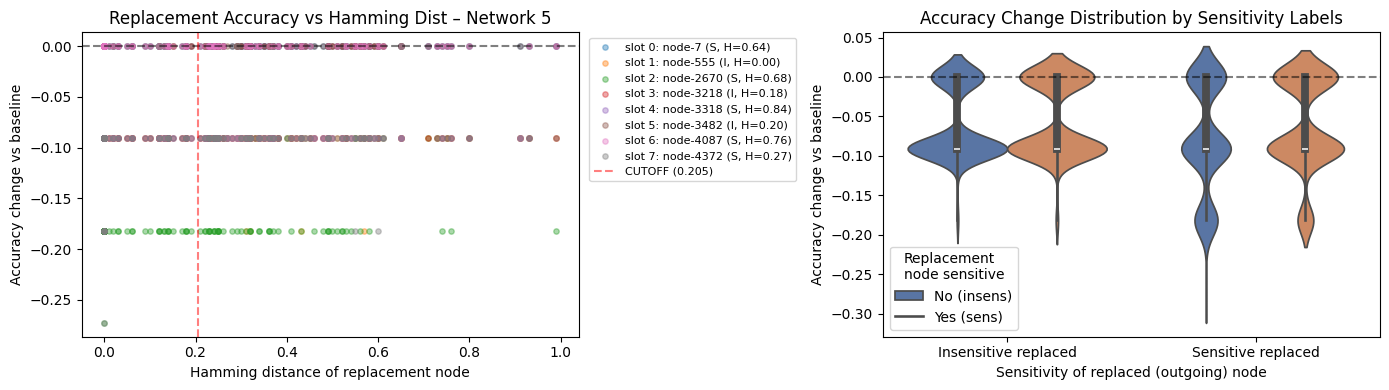

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: accuracy change vs replacement Hamming distance
ax = axes[0]
for slot_idx, replaced_node in enumerate(rep_nodes):
    sub = replacement_df[replacement_df.slot_idx == slot_idx]
    is_sens = bool(B[REP_IDX][replaced_node] > CUTOFF)
    ax.scatter(
        sub['replacement_hamming'],
        sub['accuracy_change'],
        alpha=0.4, s=15,
        label=f'slot {slot_idx}: node-{replaced_node} ({"S" if is_sens else "I"}, H={B[REP_IDX][replaced_node]:.2f})',
    )
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.axvline(CUTOFF, color='red', linestyle='--', alpha=0.5, label=f'CUTOFF ({CUTOFF:.3f})')
ax.set_xlabel('Hamming distance of replacement node')
ax.set_ylabel('Accuracy change vs baseline')
ax.set_title(f'Replacement Accuracy vs Hamming Dist – Network {REP_IDX}')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

# Right: violin plot of accuracy change split by replacement sensitivity
ax2 = axes[1]
sns.violinplot(
    data=replacement_df,
    x='replaced_sensitive',
    y='accuracy_change',
    hue='replacement_sensitive',
    palette={True: '#DD8452', False: '#4C72B0'},
    split=False,
    ax=ax2,
)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_xticklabels(['Insensitive replaced', 'Sensitive replaced'])
ax2.set_xlabel('Sensitivity of replaced (outgoing) node')
ax2.set_ylabel('Accuracy change vs baseline')
ax2.set_title('Accuracy Change Distribution by Sensitivity Labels')
ax2.legend(title='Replacement\nnode sensitive', labels=['No (insens)', 'Yes (sens)'])

plt.tight_layout()
plt.show()

## Section 4: Conditional Entropy H(Drug | nodes) Across GA Generations

**Quantity**: H(Drug | node states) — how uncertain are we about the drug label given the
current best-8 node states? Lower = better. As the GA evolves, this should decrease.

For 8 binary nodes there are 256 possible states; we compute the empirical conditional entropy
directly from the states data (no RF needed).

H(Drug) ≈ log₂(10) = 3.32 bits under a uniform drug distribution.

In [32]:
H_DRUG_UNIFORM = np.log2(10)  # upper bound if drugs are equally likely

def compute_conditional_entropy(node_cols_: List[str], states_: pd.DataFrame) -> float:
    """H(Drug | node_states) computed empirically from states_.
    states_ must have a 'Drug' column and the given node columns.
    """
    df_ = states_.copy()
    # Encode node state as a tuple of ints
    df_['_state'] = list(zip(*[df_[c].astype(int) for c in node_cols_]))
    total = len(df_)
    h_cond = 0.0
    for state, grp in df_.groupby('_state', sort=False):
        p_state = len(grp) / total
        drug_counts = grp['Drug'].value_counts()
        p_drug_given_state = drug_counts / drug_counts.sum()
        h_cond += p_state * scipy_entropy(p_drug_given_state, base=2)
    return h_cond

print(f'H(Drug) upper bound (uniform over 10 drugs): {H_DRUG_UNIFORM:.4f} bits')

H(Drug) upper bound (uniform over 10 drugs): 3.3219 bits


In [33]:
# States for the representative network, with 'Drug' column
rep_states_with_drug = states_df[states_df['original_network_idx'] == REP_IDX].copy()
rep_states_with_drug = rep_states_with_drug.rename(columns={'drug_name': 'Drug'})

# k=8 generation trajectory for representative network
k8_traj = feature_df[
    (feature_df.original_network_idx == REP_IDX) &
    (feature_df.max_num_features == 8)
].sort_values('generation')

h_rows = []
for _, row in k8_traj.iterrows():
    gen_nodes = sorted([int(n.split('-')[1]) for n in row.features])
    gen_cols  = [f'node-{n}' for n in gen_nodes]
    h = compute_conditional_entropy(gen_cols, rep_states_with_drug)
    h_rows.append({
        'generation':   row.generation,
        'best_accuracy': row.best_accuracy,
        'h_drug_given_nodes': h,
        'nodes': gen_nodes,
    })

h_gen_df = pd.DataFrame(h_rows)

# Baseline: H(Drug | 8 random nodes) — 100 samples
print('Computing random baseline (100 samples)...')
random_hs = []
for _ in range(100):
    rand_nodes = np.random.choice(N, size=8, replace=False)
    rand_cols  = [f'node-{n}' for n in rand_nodes]
    random_hs.append(compute_conditional_entropy(rand_cols, rep_states_with_drug))

baseline_h_mean = np.mean(random_hs)
baseline_h_std  = np.std(random_hs)

print(f'H(Drug | best k=8 at gen 0):    {h_gen_df.h_drug_given_nodes.iloc[0]:.4f} bits')
print(f'H(Drug | best k=8 at final gen): {h_gen_df.h_drug_given_nodes.iloc[-1]:.4f} bits')
print(f'H(Drug | random 8 nodes):        {baseline_h_mean:.4f} ± {baseline_h_std:.4f} bits')
print(f'H(Drug) uniform upper bound:     {H_DRUG_UNIFORM:.4f} bits')

Computing random baseline (100 samples)...
H(Drug | best k=8 at gen 0):    1.7964 bits
H(Drug | best k=8 at final gen): 0.5830 bits
H(Drug | random 8 nodes):        2.5085 ± 0.4297 bits
H(Drug) uniform upper bound:     3.3219 bits


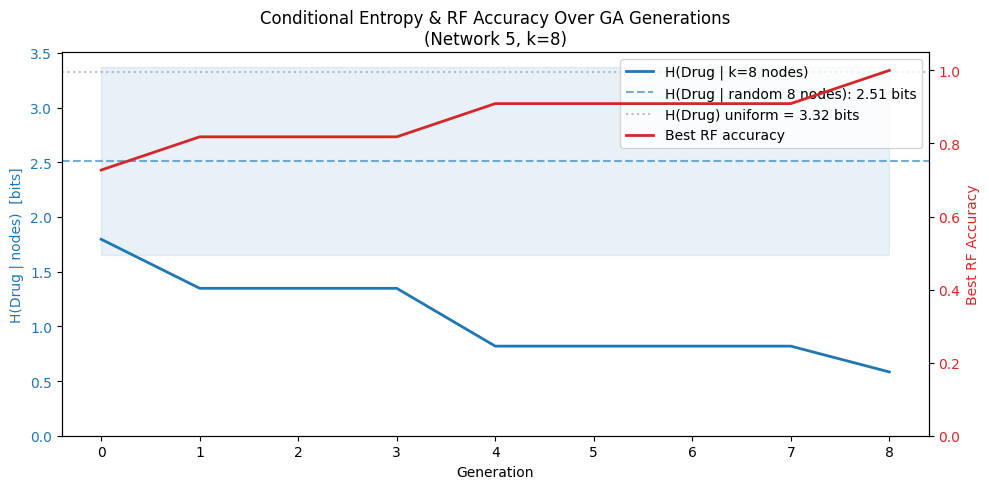

In [34]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_h   = '#1f77b4'
color_acc = '#d62728'

# H(Drug | nodes)
ax1.plot(h_gen_df.generation, h_gen_df.h_drug_given_nodes,
         color=color_h, lw=2, label='H(Drug | k=8 nodes)')
ax1.axhline(baseline_h_mean, color=color_h, linestyle='--', alpha=0.6,
            label=f'H(Drug | random 8 nodes): {baseline_h_mean:.2f} bits')
ax1.fill_between(
    h_gen_df.generation,
    baseline_h_mean - 2*baseline_h_std,
    baseline_h_mean + 2*baseline_h_std,
    alpha=0.1, color=color_h,
)
ax1.axhline(H_DRUG_UNIFORM, color='gray', linestyle=':', alpha=0.5,
            label=f'H(Drug) uniform = {H_DRUG_UNIFORM:.2f} bits')
ax1.set_ylim(bottom=0)
ax1.set_xlabel('Generation')
ax1.set_ylabel('H(Drug | nodes)  [bits]', color=color_h)
ax1.tick_params(axis='y', labelcolor=color_h)

# RF best accuracy (secondary y-axis)
ax2 = ax1.twinx()
ax2.plot(h_gen_df.generation, h_gen_df.best_accuracy,
         color=color_acc, lw=2, linestyle='-', label='Best RF accuracy')
ax2.set_ylabel('Best RF Accuracy', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(0, 1.05)

ax1.set_title(f'Conditional Entropy & RF Accuracy Over GA Generations\n(Network {REP_IDX}, k=8)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

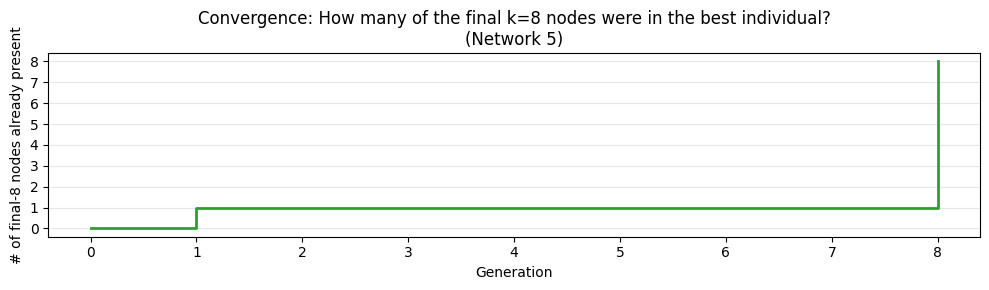

In [35]:
# Track which nodes appear in the best individual at each generation
final_nodes_set = set(rep_nodes)
node_presence = h_gen_df['nodes'].apply(
    lambda ns: sum(n in final_nodes_set for n in ns)
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(h_gen_df.generation, node_presence, drawstyle='steps-post', color='#2ca02c', lw=2)
ax.set_xlabel('Generation')
ax.set_ylabel('# of final-8 nodes already present')
ax.set_title(f'Convergence: How many of the final k=8 nodes were in the best individual?\n(Network {REP_IDX})')
ax.set_yticks(list(range(9)))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Additional Analyses

### 5a: RF Feature Importances
Which of the 4 nodes does the Random Forest rely on most?

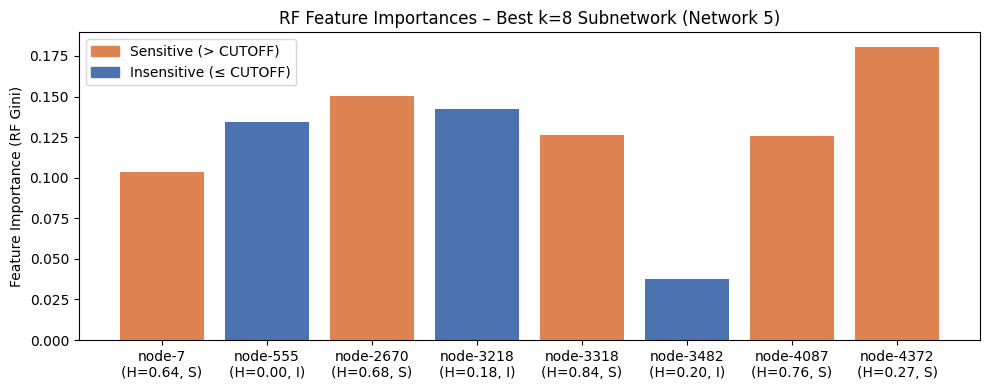

  node-7 (H=0.64, S): importance=0.1032, sensitive=True
  node-555 (H=0.00, I): importance=0.1342, sensitive=False
  node-2670 (H=0.68, S): importance=0.1501, sensitive=True
  node-3218 (H=0.18, I): importance=0.1421, sensitive=False
  node-3318 (H=0.84, S): importance=0.1266, sensitive=True
  node-3482 (H=0.20, I): importance=0.0377, sensitive=False
  node-4087 (H=0.76, S): importance=0.1255, sensitive=True
  node-4372 (H=0.27, S): importance=0.1805, sensitive=True


In [40]:
X_rep = rep_states[rep_node_cols].values
y_rep = rep_states['Drug'].values

clf = RandomForestClassifier(n_estimators=200, random_state=SEED)
clf.fit(X_rep, y_rep)
importances = clf.feature_importances_

node_labels = [
    f'node-{n}\n(H={B[REP_IDX][n]:.2f}, {"S" if B[REP_IDX][n] > CUTOFF else "I"})'
    for n in rep_nodes
]
colors = ['#DD8452' if B[REP_IDX][n] > CUTOFF else '#4C72B0' for n in rep_nodes]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(node_labels, importances, color=colors)
ax.set_ylabel('Feature Importance (RF Gini)')
ax.set_title(f'RF Feature Importances – Best k=8 Subnetwork (Network {REP_IDX})')
ax.legend(handles=[
    Patch(color='#DD8452', label='Sensitive (> CUTOFF)'),
    Patch(color='#4C72B0', label='Insensitive (≤ CUTOFF)'),
])
plt.tight_layout()
plt.show()

for lbl, imp, node in zip(node_labels, importances, rep_nodes):
    print(f'  {lbl.replace(chr(10), " ")}: importance={imp:.4f}, sensitive={B[REP_IDX][node]>CUTOFF}')

### 5b: Exact Shapley Values (k=8, 2⁸ = 256 subsets)

Computing Shapley values (256 subset evaluations)...
  node-7 (slot 0, sensitive=True): Shapley=0.0921
  node-555 (slot 1, sensitive=False): Shapley=0.1264
  node-2670 (slot 2, sensitive=True): Shapley=0.1817
  node-3218 (slot 3, sensitive=False): Shapley=0.1251
  node-3318 (slot 4, sensitive=True): Shapley=0.1163
  node-3482 (slot 5, sensitive=False): Shapley=0.0075
  node-4087 (slot 6, sensitive=True): Shapley=0.0843
  node-4372 (slot 7, sensitive=True): Shapley=0.1747


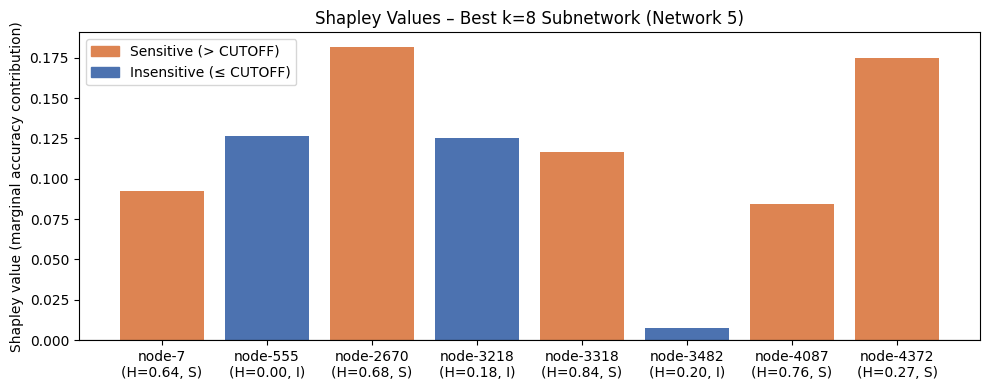

In [37]:
from math import factorial

def subset_accuracy(slot_indices: Tuple[int, ...]) -> float:
    """Accuracy for a given subset of the 8 node slots (0-indexed into rep_nodes)."""
    if not slot_indices:
        return 1 / len(rep_states['Drug'].unique())  # random-chance baseline
    cols = [rep_node_cols[i] for i in slot_indices]
    p, _ = train_and_test(rep_states, num_trials=2, original_network_idx=REP_IDX, dep_vars=cols)
    return p['correct'].mean()

n_players = 8
print(f'Computing Shapley values ({2**n_players} subset evaluations)...')

shapley_vals = []
for i in range(n_players):
    others = [j for j in range(n_players) if j != i]
    phi_i = 0.0
    for size in range(n_players):
        for S in combinations(others, size):
            weight = factorial(size) * factorial(n_players - size - 1) / factorial(n_players)
            v_with    = subset_accuracy(S + (i,))
            v_without = subset_accuracy(S)
            phi_i += weight * (v_with - v_without)
    shapley_vals.append(phi_i)
    print(f'  node-{rep_nodes[i]} (slot {i}, sensitive={bool(B[REP_IDX][rep_nodes[i]]>CUTOFF)}): Shapley={phi_i:.4f}')

node_labels = [
    f'node-{n}\n(H={B[REP_IDX][n]:.2f}, {"S" if B[REP_IDX][n] > CUTOFF else "I"})'
    for n in rep_nodes
]
colors = ['#DD8452' if B[REP_IDX][n] > CUTOFF else '#4C72B0' for n in rep_nodes]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(node_labels, shapley_vals, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Shapley value (marginal accuracy contribution)')
ax.set_title(f'Shapley Values – Best k=8 Subnetwork (Network {REP_IDX})')
ax.legend(handles=[
    Patch(color='#DD8452', label='Sensitive (> CUTOFF)'),
    Patch(color='#4C72B0', label='Insensitive (≤ CUTOFF)'),
])
plt.tight_layout()
plt.show()

### 5c: Drug Confusion Matrix Analysis

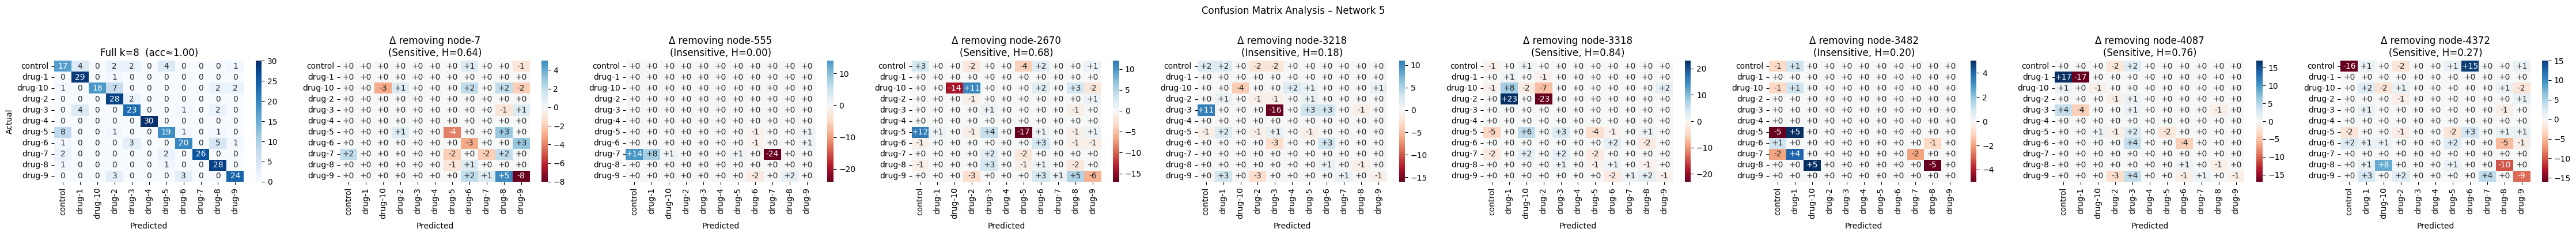

In [38]:
def get_cm(dep_cols: List[str], states: pd.DataFrame, seed: int = SEED):
    """Train RF and return (confusion_matrix, drug_labels)."""
    X_all = states[dep_cols].values
    y_all = states['Drug'].values
    drugs = sorted(states['Drug'].unique())
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=0.3, stratify=y_all, random_state=seed
    )
    clf_ = RandomForestClassifier(n_estimators=100, random_state=seed)
    clf_.fit(X_tr, y_tr)
    return confusion_matrix(y_te, clf_.predict(X_te), labels=drugs), drugs

cm_base, drugs = get_cm(rep_node_cols, rep_states)

n_slots = len(rep_nodes)
fig, axes = plt.subplots(1, n_slots + 1, figsize=(5 * (n_slots + 1), 4))

# Baseline confusion matrix
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=drugs, yticklabels=drugs, ax=axes[0])
axes[0].set_title(f'Full k=8  (acc≈{BASE_ACC:.2f})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Per-node removal
for i, removed_node in enumerate(rep_nodes):
    remaining_cols = [c for c in rep_node_cols if c != f'node-{removed_node}']
    cm_rem, _ = get_cm(remaining_cols, rep_states)
    cm_delta = cm_rem.astype(float) - cm_base.astype(float)
    is_sens = bool(B[REP_IDX][removed_node] > CUTOFF)
    sns.heatmap(cm_delta, annot=True, fmt='+.0f', cmap='RdBu', center=0,
                xticklabels=drugs, yticklabels=drugs, ax=axes[i + 1])
    axes[i + 1].set_title(
        f'Δ removing node-{removed_node}\n({"Sensitive" if is_sens else "Insensitive"}, H={B[REP_IDX][removed_node]:.2f})'
    )
    axes[i + 1].set_xlabel('Predicted')
    axes[i + 1].set_ylabel('')

plt.suptitle(f'Confusion Matrix Analysis – Network {REP_IDX}', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

### 5d: Pairwise Mutual Information Between the k=4 Nodes

Are the selected nodes redundant with each other?  
I(node_i; node_j) = H(node_i) + H(node_j) − H(node_i, node_j)

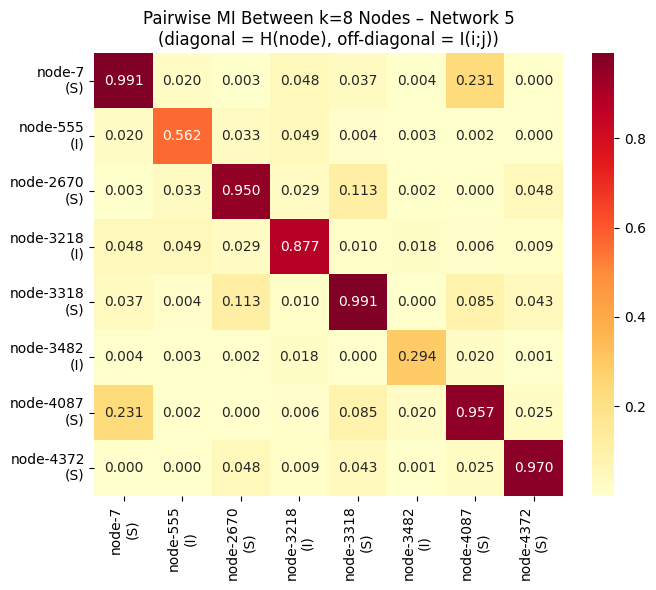

Off-diagonal (pairwise MI):
  I(node-7; node-555) = 0.0197 bits
  I(node-7; node-2670) = 0.0032 bits
  I(node-7; node-3218) = 0.0477 bits
  I(node-7; node-3318) = 0.0373 bits
  I(node-7; node-3482) = 0.0035 bits
  I(node-7; node-4087) = 0.2313 bits
  I(node-7; node-4372) = 0.0001 bits
  I(node-555; node-2670) = 0.0326 bits
  I(node-555; node-3218) = 0.0486 bits
  I(node-555; node-3318) = 0.0045 bits
  I(node-555; node-3482) = 0.0027 bits
  I(node-555; node-4087) = 0.0018 bits
  I(node-555; node-4372) = 0.0002 bits
  I(node-2670; node-3218) = 0.0285 bits
  I(node-2670; node-3318) = 0.1132 bits
  I(node-2670; node-3482) = 0.0024 bits
  I(node-2670; node-4087) = 0.0000 bits
  I(node-2670; node-4372) = 0.0483 bits
  I(node-3218; node-3318) = 0.0104 bits
  I(node-3218; node-3482) = 0.0178 bits
  I(node-3218; node-4087) = 0.0060 bits
  I(node-3218; node-4372) = 0.0087 bits
  I(node-3318; node-3482) = 0.0001 bits
  I(node-3318; node-4087) = 0.0853 bits
  I(node-3318; node-4372) = 0.0431 bits


In [39]:
def marginal_entropy(col: str, df: pd.DataFrame) -> float:
    p = df[col].value_counts(normalize=True)
    return scipy_entropy(p, base=2)

def joint_entropy(col_a: str, col_b: str, df: pd.DataFrame) -> float:
    p = df.groupby([col_a, col_b]).size() / len(df)
    return scipy_entropy(p, base=2)

def pairwise_mi(col_a: str, col_b: str, df: pd.DataFrame) -> float:
    return marginal_entropy(col_a, df) + marginal_entropy(col_b, df) - joint_entropy(col_a, col_b, df)

# Compute MI matrix for the k=8 nodes
k = len(rep_node_cols)
mi_matrix = np.zeros((k, k))
for i in range(k):
    for j in range(k):
        mi_matrix[i, j] = pairwise_mi(rep_node_cols[i], rep_node_cols[j], rep_states_with_drug)

short_labels = [
    f'node-{n}\n({"S" if B[REP_IDX][n]>CUTOFF else "I"})'
    for n in rep_nodes
]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    mi_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=short_labels, yticklabels=short_labels, ax=ax,
)
ax.set_title(f'Pairwise MI Between k=8 Nodes – Network {REP_IDX}\n(diagonal = H(node), off-diagonal = I(i;j))')
plt.tight_layout()
plt.show()

print('Off-diagonal (pairwise MI):')
for i in range(k):
    for j in range(i+1, k):
        print(f'  I(node-{rep_nodes[i]}; node-{rep_nodes[j]}) = {mi_matrix[i,j]:.4f} bits')

## Further Ideas

### 1. Cross-Network Node Consistency
Do the same nodes appear in the best-4 across multiple network realizations?
High consistency → structurally important nodes (e.g., near drug targets).
Low consistency → the GA finds many equally good solutions (flat fitness landscape).

```python
from collections import Counter
node_freq = Counter(n for info in best_k4.values() for n in info['nodes'])
pd.DataFrame(node_freq.most_common(20), columns=['node', 'times_selected'])
```

### 2. GA Population Diversity
We only tracked the *best* individual's features. But how many unique nodes appear
across the **whole population** at each generation? Narrow diversity → premature convergence.
This requires saving the full population per generation in the GA script.

### 3. Degree & Topology of Selected Nodes
Are the k=4 selected nodes high-degree hubs or leaf nodes?
Use `network_df` to compute in-degree and out-degree per selected node.
Are sensitive nodes high out-degree (signal propagators) while insensitive are high in-degree?

### 4. Per-Drug Sensitivity of Selected Nodes
Not all sensitive nodes respond to all drugs equally.
Instead of averaging over drugs to get B[network][node], decompose:
`B_per_drug[network][drug][node]` — which node is most sensitive to which drug?
This could reveal drug-specific roles for each of the 4 selected nodes.

### 5. Multi-Seed GA Consistency
Re-run the GA on the representative network with a different random seed.
Do you recover the same k=4 nodes? If yes → unique optimum; if no → flat landscape.

### 6. Drug-Target Proximity
Given the perturbation data (which nodes are drug targets), compute the
shortest path in the network from each drug target to each of the 4 selected nodes.
Sensitive nodes should be 1–2 hops downstream; insensitive 'anchor' nodes might be
at intermediate distances or in a separate network region entirely.

### 7. Comparing k=4 vs k=16 vs k=64 GA Subnetworks
Does the composition (sensitive/insensitive fraction) of the best subnetwork change
as k grows? At large k, the GA might switch to selecting mostly sensitive nodes
since redundancy matters less.